# DVS Gesture Recognition — CNN Results Visualization

Visualize test accuracy vs. target frame count, grouped by temporal pooling mode, averaged across random seeds.

Also compare against the baseline (no temporal pooling) from the original runs.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and inspect pooled data

In [9]:
df = pd.read_csv("dvs128_cnn_09_batch8_10seeds.csv")
print(f"Total rows: {len(df)}")
print(f"Random seeds: {sorted(df['random_seed'].unique())}")
print(f"Target frames: {sorted(df['target_frames'].unique())}")
print(f"Pooling modes: {sorted(df['pooling_mode'].unique())}")
df.head()

Total rows: 189
Random seeds: [np.int64(6), np.int64(13), np.int64(42), np.int64(44), np.int64(45), np.int64(59), np.int64(93), np.int64(96), np.int64(98)]
Target frames: [np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800)]
Pooling modes: ['avg', 'linear', 'max']


,name,train_data_size,val_data_size,random_seed,representation,train_acc,val_acc,test_acc,num_epochs,batch_size,target_frames,pooling_mode
0,time_window_09_42_8_200_max,0.9,0.1,42,time_window,0.992783,0.897196,0.840909,8,8,200,max
1,time_window_09_42_8_300_max,0.9,0.1,42,time_window,0.991753,0.925234,0.871212,8,8,300,max
2,time_window_09_42_8_400_max,0.9,0.1,42,time_window,0.997938,0.897196,0.901515,8,8,400,max
3,time_window_09_42_8_500_max,0.9,0.1,42,time_window,1.000000,0.943925,0.875000,10,8,500,max
4,time_window_09_42_8_600_max,0.9,0.1,42,time_window,1.000000,0.934579,0.875000,14,8,600,max


## Load baseline results (no pooling)

In [15]:
df_baseline = pd.read_csv("../results/dvs128_cnn_09_batch8_10seeds.txt")
df_baseline_tw = df_baseline[df_baseline["representation"] == "time_window"].copy()
print(f"Baseline time_window rows: {len(df_baseline_tw)}")

baseline_stats = pd.Series({
    "train_acc_mean": df_baseline_tw["train_acc"].mean(),
    "train_acc_std":  df_baseline_tw["train_acc"].std(),
    "test_acc_mean":  df_baseline_tw["test_acc"].mean(),
    "test_acc_std":   df_baseline_tw["test_acc"].std(),
})


print(f"Baseline test acc: {baseline_stats['test_acc_mean']:.4f} \u00b1 {baseline_stats['test_acc_std']:.4f}")
baseline_stats

Baseline time_window rows: 9
Baseline test acc: 0.8847 ± 0.0291


train_acc_mean    0.916770
train_acc_std     0.023423
test_acc_mean     0.884680
test_acc_std      0.029102
dtype: float64

## Average accuracies across random seeds (pooled runs)

In [16]:
avg_df = (
    df.groupby(["target_frames", "pooling_mode"])
    .agg(
        train_acc_mean=("train_acc", "mean"),
        train_acc_std=("train_acc", "std"),
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        n_runs=("test_acc", "count"),
    )
    .reset_index()
)
avg_df

,target_frames,pooling_mode,train_acc_mean,train_acc_std,val_acc_mean,val_acc_std,test_acc_mean,test_acc_std,n_runs
0,200,avg,0.998511,0.004467,0.928349,0.028806,0.887205,0.011641,9
1,200,linear,0.998740,0.002173,0.934579,0.033042,0.877104,0.018950,9
2,200,max,0.999198,0.002406,0.938733,0.020428,0.870791,0.017301,9
3,300,avg,0.995647,0.008880,0.927310,0.035211,0.886785,0.020437,9
4,300,linear,0.998855,0.001818,0.934579,0.034339,0.877946,0.014643,9
5,300,max,0.998855,0.002749,0.941848,0.017963,0.882155,0.025722,9
6,400,avg,0.998053,0.005842,0.948079,0.014105,0.884259,0.015515,9
7,400,linear,0.997365,0.007904,0.929387,0.023878,0.869529,0.029832,9
8,400,max,0.999771,0.000687,0.941848,0.021300,0.890152,0.019864,9
9,500,avg,1.000000,0.000000,0.952233,0.022626,0.880471,0.013273,9


## Test accuracy vs. frame count by pooling mode (with baseline)

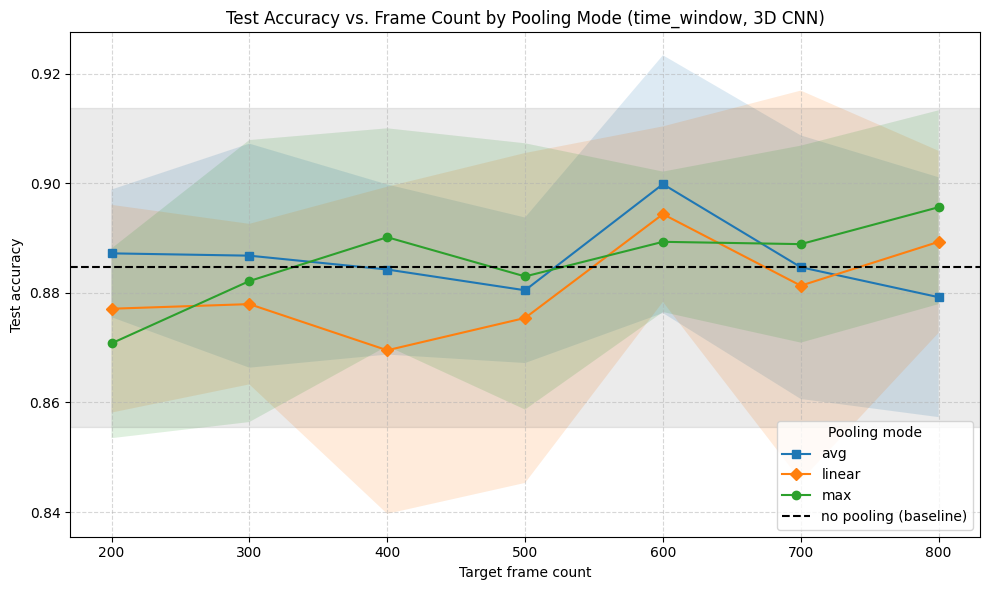

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

markers = {"max": "o", "avg": "s", "linear": "D"}

for mode, grp in avg_df.groupby("pooling_mode"):
    grp = grp.sort_values("target_frames")
    ax.plot(
        grp["target_frames"],
        grp["test_acc_mean"],
        marker=markers.get(mode, "x"),
        label=mode,
    )
    ax.fill_between(
        grp["target_frames"],
        grp["test_acc_mean"] - grp["test_acc_std"],
        grp["test_acc_mean"] + grp["test_acc_std"],
        alpha=0.15,
    )

# Baseline (no pooling)
bl_mean = baseline_stats["test_acc_mean"]
bl_std = baseline_stats["test_acc_std"]
ax.axhline(bl_mean, color="black", linestyle="--", linewidth=1.5, label="no pooling (baseline)")
ax.axhspan(bl_mean - bl_std, bl_mean + bl_std, color="black", alpha=0.08)

ax.set_xlabel("Target frame count")
ax.set_ylabel("Test accuracy")
ax.set_title("Test Accuracy vs. Frame Count by Pooling Mode (time_window, 3D CNN)")
ax.legend(title="Pooling mode")
ax.set_xticks(sorted(avg_df["target_frames"].unique()))
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
fig.savefig("output.png", dpi=150, bbox_inches="tight")